<a href="https://colab.research.google.com/github/nursena8/paligemma2-research/blob/main/VQA_Visual_Question_Answering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 29.8 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login
login()

In [10]:
import torch
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration
from PIL import Image
import gc

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


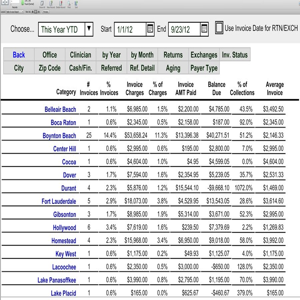

In [12]:
image_path = "/content/table.png"
image = Image.open(image_path).convert("RGB")

prompt = "answer en What is the invoice amount for Boynton Beach?"

image.resize((300, 300))  # notebook'ta hızlı önizleme

In [14]:
# --- Üç çözünürlük ile deneme ---
checkpoints = {
    "224px²": "google/paligemma2-3b-mix-224",
    "448px²": "google/paligemma2-3b-mix-448",
}

results = {}

for label, ckpt in checkpoints.items():
    print(f"\n--- {label} ({ckpt}) yükleniyor ---")

    processor = AutoProcessor.from_pretrained(ckpt)
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        ckpt,
        torch_dtype=torch.bfloat16,
    ).to(device)
    model.eval()

    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch.bfloat16)
    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        generation = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
        )
        generation = generation[0][input_len:]
        decoded = processor.decode(generation, skip_special_tokens=True)

    results[label] = decoded
    print(f"{label} cevabı: {decoded}")

    # T4'ün belleği sınırlı — bir sonraki modele geçmeden önce temizle
    del model, processor, inputs, generation
    gc.collect()
    torch.cuda.empty_cache()


--- 224px² (google/paligemma2-3b-mix-224) yükleniyor ---


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

[transformers] You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


448px² cevabı: $53,658.24


In [ ]:
# 448px² cevabı: $53,658.24

In [15]:
# Karşılaştırmalı özet
import pandas as pd

df = pd.DataFrame(list(results.items()), columns=["Çözünürlük", "Model Cevabı"])
df

,Çözünürlük,Model Cevabı
0,224px²,"$91,368.59"
1,448px²,"$53,658.24"
